# Worksheet 7 - Neural networks

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## 1 - Data

In [2]:
spectra = np.load('spectra.npy')
labels = pd.read_csv('labels_table.csv')
auxillary = pd.read_csv('auxillary_table.csv')

In [3]:
labels

,Unnamed: 0,planet_ID,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,0,train1,0.559620,863.394770,-8.865868,-6.700707,-5.557561,-8.957615,-3.097540
1,1,train2,1.118308,1201.700465,-4.510258,-8.228966,-3.565427,-7.807424,-3.633658
2,2,train3,0.400881,1556.096477,-7.225472,-6.931472,-3.081975,-8.567854,-5.378472
3,3,train4,0.345974,1268.624884,-7.461157,-5.853334,-3.044711,-5.149378,-3.815568
4,4,train5,0.733184,1707.323564,-4.140844,-7.460278,-3.181793,-5.996593,-4.535345
...,...,...,...,...,...,...,...,...,...
41418,41418,train41419,1.430950,1167.563319,-7.556565,-7.075889,-4.735715,-7.532563,-7.854443
41419,41419,train41420,0.277752,649.703932,-7.434332,-7.161510,-5.274940,-4.100312,-3.651804
41420,41420,train41421,0.136016,1445.371723,-5.525906,-5.079240,-4.945121,-5.787630,-8.015444
41421,41421,train41422,0.707851,653.284686,-4.616695,-8.782546,-3.767229,-3.221403,-8.427805


In [4]:
auxillary

,planet_ID,star_distance,star_mass_kg,star_radius_m,star_temperature,planet_mass_kg,planet_orbital_period,planet_distance,planet_surface_gravity
0,train1,530.7650,1.968526e+30,6.678720e+08,5636.0,3.990923e+26,9.668577,0.088530,16.642039
1,train2,440.0890,1.948642e+30,7.235280e+08,5449.0,4.977001e+26,4.218028,0.050752,5.197135
2,train3,1126.3700,2.147483e+30,7.791840e+08,5675.0,9.686804e+25,2.828042,0.040158,7.871718
3,train4,1257.1600,2.048062e+30,7.374420e+08,5849.0,4.486340e+25,3.855604,0.048601,4.894681
4,train5,211.5530,2.525281e+30,1.092249e+09,6200.0,2.416329e+26,3.076340,0.044833,5.870151
...,...,...,...,...,...,...,...,...,...
41418,train41419,703.3020,1.988410e+30,7.722270e+08,5821.0,7.125924e+26,5.370647,0.060024,4.544766
41419,train41420,72.7998,1.292466e+30,4.035060e+08,4258.0,7.709155e+25,6.342000,0.058089,13.050003
41420,train41421,1786.4800,1.789569e+30,7.096140e+08,6002.0,2.794853e+25,3.546511,0.043946,19.728779
41421,train41422,329.0410,1.849221e+30,6.748290e+08,5519.0,1.400242e+26,22.631964,0.152856,3.649544


## 2 - Data visualisation and pre-processing

**Plot a few example spectra and the mean and standard deviation of all spectra:**

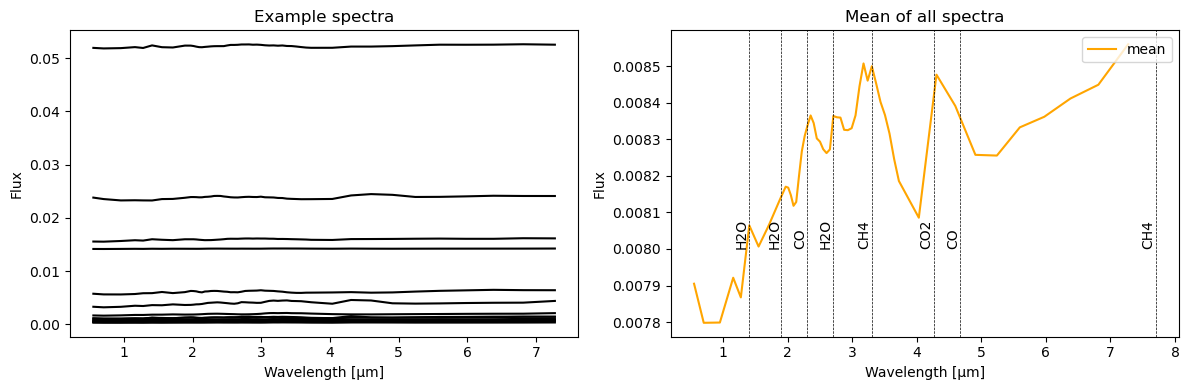

In [ ]:
random = np.random.randint(0, 41423, size=15)
mean_spectrum = spectra[:, :, 1].mean(axis=0)

emission_lines = {
    'H2O': [1.4, 1.9, 2.7],
    'CO2': [4.26],
    'CO': [2.3, 4.67],
    'CH4': [3.3, 7.7],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for i in random:
    ax1.plot(spectra[i,:,0], spectra[i, :, 1], color='black')

ax1.set_xlabel('Wavelength [μm]')
ax1.set_ylabel('Flux')
ax1.set_title('Example spectra')

ax2.plot(spectra[0,:,0], mean_spectrum, color='orange', label='mean')
ax2.set_xlabel('Wavelength [μm]')
ax2.set_ylabel('Flux')
ax2.set_title('Mean of all spectra')

for molecule, wavelengths in emission_lines.items():
    for w in wavelengths:
        ax2.axvline(x=w, linewidth=0.5, color='black', linestyle='--')
        ax2.text(w, 0.008, molecule, rotation=90, verticalalignment='bottom', horizontalalignment='right')

plt.tight_layout()
plt.legend(loc='upper right')
plt.show()

## 3 - Neural Network Model

**Split data into training, validation and test data (70/15/15):**

The spectra are the input data X, the labels (so the planets properties) are the targets y. The auxillary data are additional inputs that should lead to better predictions.

In [7]:
# split 70/30
X_train, X_temp, y_train, y_temp, aux_train, aux_temp = train_test_split(spectra, labels, auxillary, test_size=0.30, random_state=42)

# split again into test and validation sample (15/15)
X_val, X_test, y_val, y_test, aux_val, aux_test = train_test_split(X_temp, y_temp, aux_temp, test_size=0.50, random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(28996, 52, 4)
(6213, 52, 4)
(6214, 52, 4)


**Prepare the data:**

Convert the labels and the auxillary data into a numpy array. Also, scale all the data to reach better results from the model (in order to do this, first the data has to be flattened, because the StandardScaler() expects a 2D array.)

In [8]:
# Keep only the target columns, exclude indices and IDs and convert to numpy array

y_train = y_train.select_dtypes(include=['float64', 'int64']).to_numpy()
y_val = y_val.select_dtypes(include=['float64', 'int64']).to_numpy()
y_test = y_test.select_dtypes(include=['float64', 'int64']).to_numpy()

In [9]:
# Same for auxillary data

target_columns = ['star_radius_m', 'star_temperature', 'planet_distance', 'planet_surface_gravity']


aux_train = aux_train[target_columns].astype(float).to_numpy()
aux_val   = aux_val[target_columns].astype(float).to_numpy()
aux_test  = aux_test[target_columns].astype(float).to_numpy()

In [10]:
# Flatten X data

X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)


# Scale the data

X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train)
X_val   = X_scaler.transform(X_val)
X_test  = X_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_val   = y_scaler.transform(y_val)
y_test  = y_scaler.transform(y_test)

aux_scaler = StandardScaler()
aux_train = aux_scaler.fit_transform(aux_train)
aux_val = aux_scaler.transform(aux_val)
aux_test = aux_scaler.transform(aux_test)


**Combine X with auxillary data:**

In [11]:
X_train_final = np.concatenate([X_train, aux_train], axis=1)
X_val_final   = np.concatenate([X_val, aux_val], axis=1)
X_test_final  = np.concatenate([X_test, aux_test], axis=1)

**Fit a feed forward neural network model to the training and validation data:**

In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train_final.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(y_train.shape[1])

])

c:\Users\helen\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile the model:**

In [13]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

**Train the model:**

In [14]:
history = model.fit(X_train_final, y_train, validation_data=(X_val_final, y_val), epochs=400, batch_size=32)

Epoch 1/400
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.8365 - mae: 0.7447 - val_loss: 0.7686 - val_mae: 0.7008
Epoch 2/400
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7815 - mae: 0.7125 - val_loss: 0.7588 - val_mae: 0.6870
Epoch 3/400
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7710 - mae: 0.7043 - val_loss: 0.7559 - val_mae: 0.6882
Epoch 4/400
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7671 - mae: 0.7008 - val_loss: 0.7528 - val_mae: 0.6832
Epoch 5/400
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7631 - mae: 0.6972 - val_loss: 0.7437 - val_mae: 0.6773
Epoch 6/400
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7525 - mae: 0.6907 - val_loss: 0.7236 - val_mae: 0.6654
Epoch 7/400
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7351 - mae: 0.6801 - val_loss: 0.7074 - val_mae: 0.6567
Epoch 8/400
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7219 - mae: 0.6714 - val_loss: 0.6996 - val_mae: 0.6526
Epoch 9/400
907/907 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/

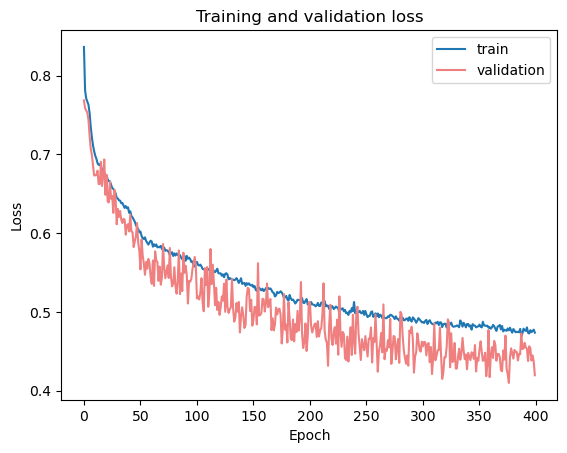

In [85]:
# Plot training and validation loss

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation', color='lightcoral')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

**Predict the test data:**

In [16]:
y_pred = model.predict(X_test_final)

195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


**Scale values back:**

In [17]:
y_pred = y_scaler.inverse_transform(y_pred)
y_true = y_scaler.inverse_transform(y_test)

**Evaluate model:**

In [18]:
test_loss, test_mae = model.evaluate(X_test_final, y_test)

print("Test loss:", test_loss)
print("Test MAE:", test_mae)

195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4166 - mae: 0.4669
Test loss: 0.4165979325771332
Test MAE: 0.4668552875518799


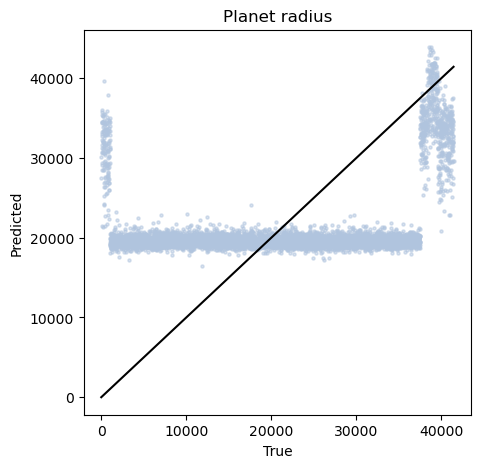

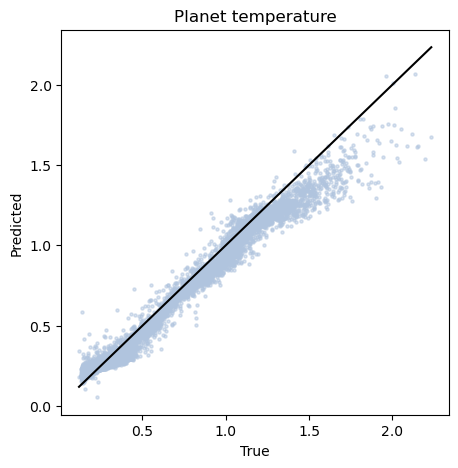

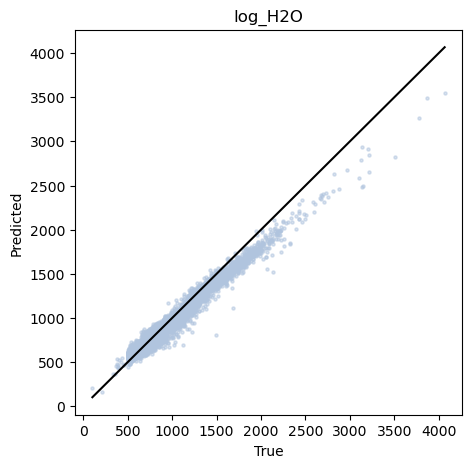

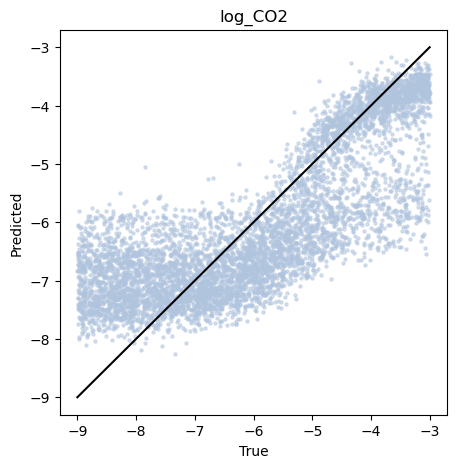

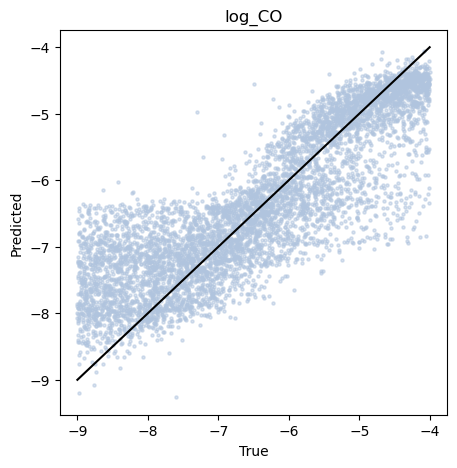

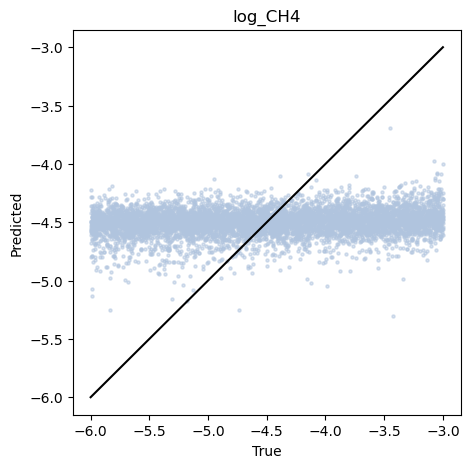

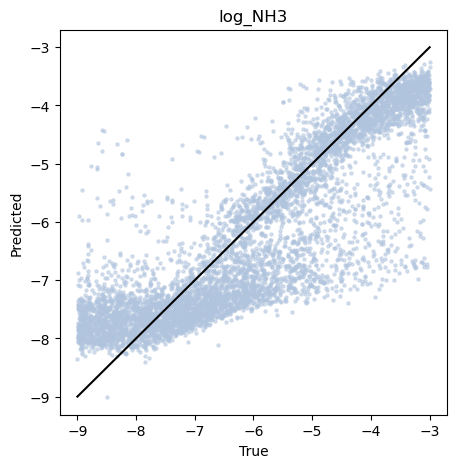

In [91]:
target_names = [
    'Planet radius',
    'Planet temperature',
    'log_H2O',
    'log_CO2',
    'log_CO',
    'log_CH4',
    'log_NH3'
]

for i, name in enumerate(target_names):

    plt.figure(figsize=(5,5))
    plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.5, s=5, color='lightsteelblue')
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(name)
    plt.plot(
        [y_true[:,i].min(), y_true[:,i].max()],
        [y_true[:,i].min(), y_true[:,i].max()], color='black'
    )

    plt.show()